<a href="https://colab.research.google.com/github/chandharshit99-cloud/agriculture-data-project/blob/main/seasonal_agriculture_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Major Project – VOIS AICTE Batch 1 2026-2027

Objective:
To analyze agricultural data across different seasons and identify meaningful patterns, trends, relationships, and differences in agricultural performance.

Problem Statement

Agricultural performance can vary across seasons because of differences in environmental conditions, farming practices, resource availability, and market conditions.

The objective of this project is to analyze the given agricultural dataset and investigate how agricultural performance differs across seasons by identifying meaningful patterns, trends, relationships, and variations.

Objectives
To explore and understand the agricultural dataset.
To clean and prepare the data for analysis.
To analyze agricultural performance across different seasons.
To identify important seasonal patterns and trends.
To examine relationships between environmental conditions and agricultural outcomes.
To compare crop performance across different seasons.
To analyze resource usage and economic performance.
To identify significant differences and unusual patterns.
To use statistical analysis and data visualization to support findings.
To provide data-driven recommendations.

In [8]:
import glob
import pandas as pd

files = glob.glob("/content/drive/MyDrive/dataset/*.csv")

df = pd.read_csv(files[0])

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# drop duplicates
df = df.drop_duplicates()

# get column types
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# fill missing numbers with median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# fill missing text with mode
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

# verify clean data
print(df.isnull().sum())
print(f"Cleaned shape: {df.shape}")





Dataset loaded successfully!
Rows: 4000
Columns: 28
Farm_ID                          0
State                            0
District                         0
Crop                             0
Season                           0
Farm_Area_Hectares               0
Rainfall_mm                      0
Avg_Temperature_C                0
Humidity_pct                     0
Sunlight_Hours_Day               0
Soil_pH                          0
Soil_Moisture_pct                0
Nitrogen_kg_ha                   0
Phosphorus_kg_ha                 0
Potassium_kg_ha                  0
Irrigation_Method                0
Fertilizer_kg_ha                 0
Pesticide_Litre_ha               0
Seed_Quality_Score               0
Yield_Tonnes_Ha                  0
Production_Tonnes                0
Market_Price_INR_Tonne           0
Total_Cost_INR                   0
Revenue_INR                      0
Profit_INR                       0
Water_Used_m3                    0
Water_Efficiency_t_per_1000m3    0
Dis

/tmp/ipykernel_777/4228712095.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Season', ax=axes[0], palette='Set2')
/tmp/ipykernel_777/4228712095.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', ax=axes[1], palette='Set2')
/tmp/ipykernel_777/4228712095.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y='Profit_INR', ax=axes[2], palette='Set2', errorbar=None)


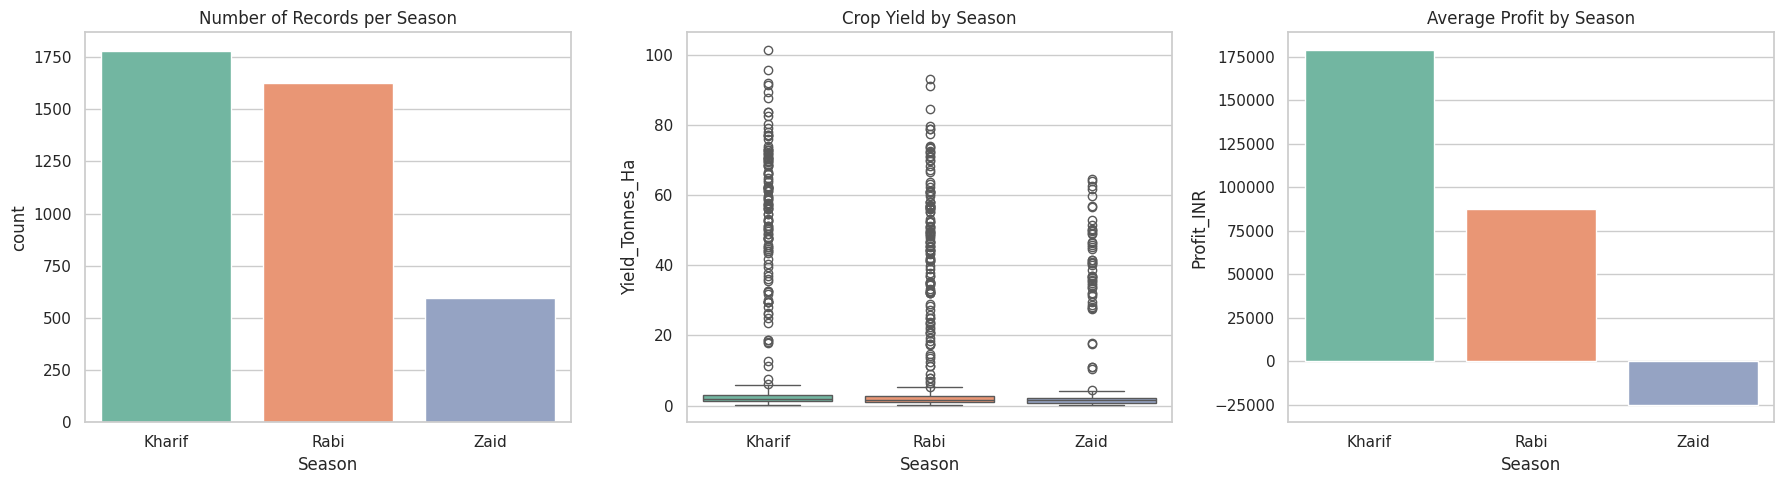

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# set plot style
sns.set_theme(style="whitegrid")

# create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. crop distribution by season
sns.countplot(data=df, x='Season', ax=axes[0], palette='Set2')
axes[0].set_title('Number of Records per Season')

# 2. yield across seasons
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', ax=axes[1], palette='Set2')
axes[1].set_title('Crop Yield by Season')

# 3. profit across seasons
sns.barplot(data=df, x='Season', y='Profit_INR', ax=axes[2], palette='Set2', errorbar=None)
axes[2].set_title('Average Profit by Season')

plt.tight_layout()
plt.show()

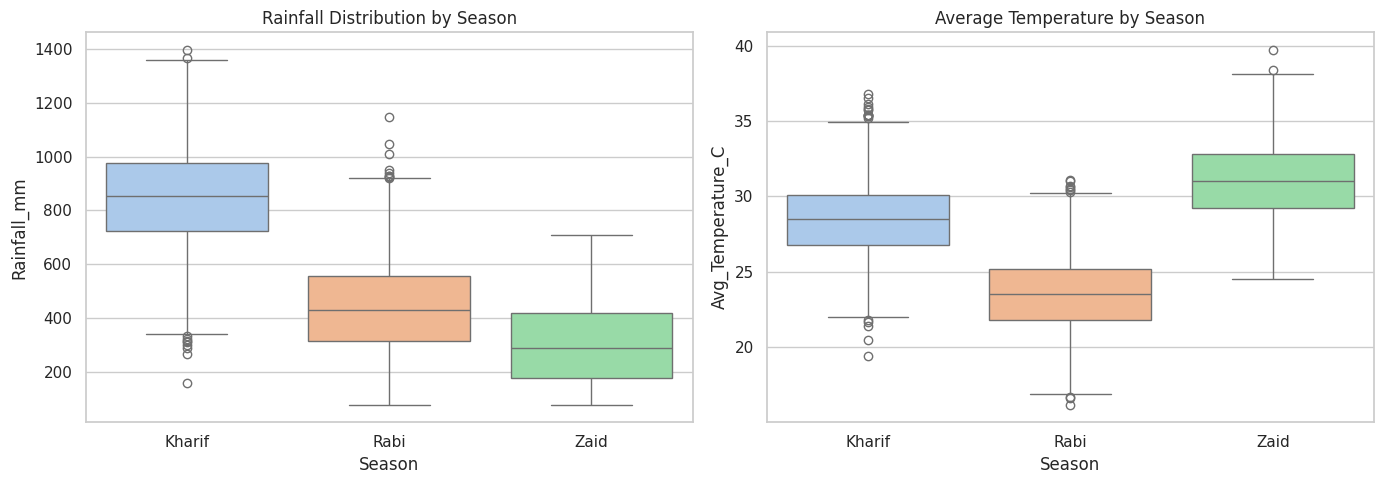

In [10]:
# create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. rainfall by season
sns.boxplot(data=df, x='Season', y='Rainfall_mm', hue='Season', legend=False, ax=axes[0], palette='pastel')
axes[0].set_title('Rainfall Distribution by Season')

# 2. temperature by season
sns.boxplot(data=df, x='Season', y='Avg_Temperature_C', hue='Season', legend=False, ax=axes[1], palette='pastel')
axes[1].set_title('Average Temperature by Season')

plt.tight_layout()
plt.show()

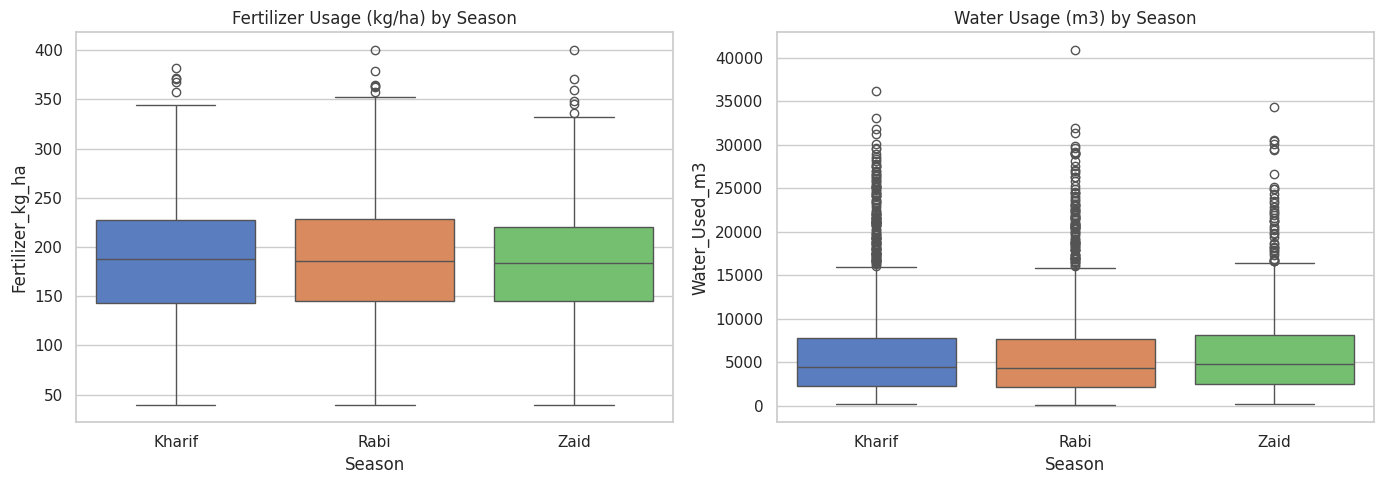

In [11]:
# create a figure with 2 subplots for resource usage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. fertilizer usage by season
sns.boxplot(data=df, x='Season', y='Fertilizer_kg_ha', hue='Season', legend=False, ax=axes[0], palette='muted')
axes[0].set_title('Fertilizer Usage (kg/ha) by Season')

# 2. water usage by season
sns.boxplot(data=df, x='Season', y='Water_Used_m3', hue='Season', legend=False, ax=axes[1], palette='muted')
axes[1].set_title('Water Usage (m3) by Season')

plt.tight_layout()
plt.show()

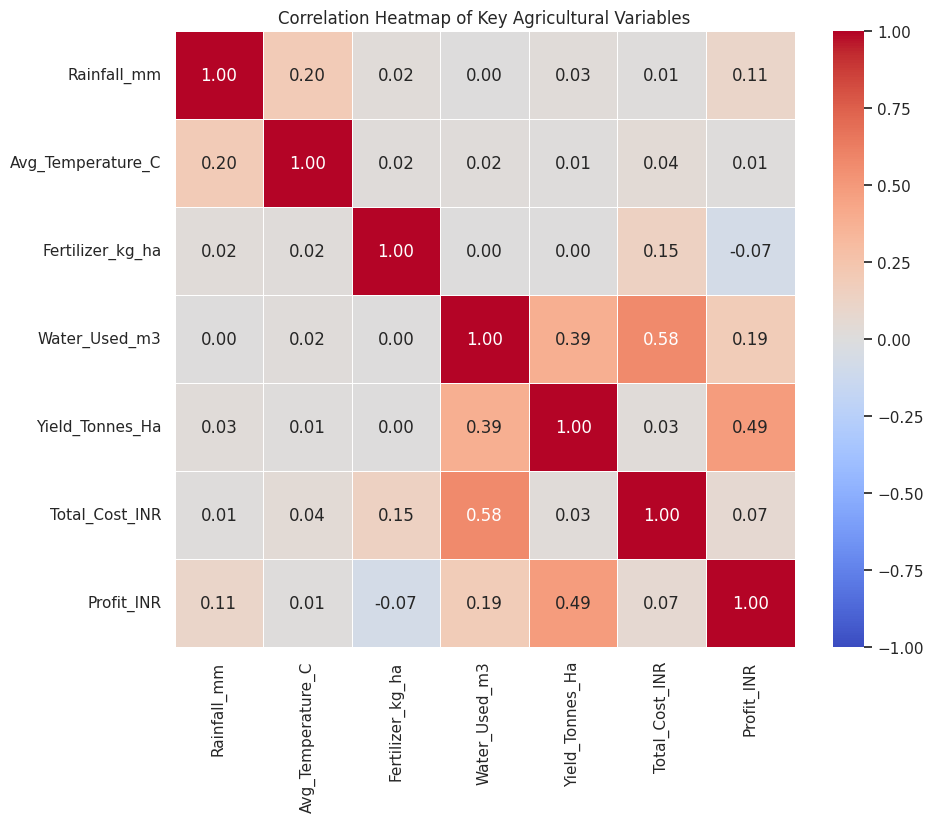

In [12]:
# Select key numerical columns for the correlation analysis
key_cols = [
    'Rainfall_mm', 'Avg_Temperature_C', 'Fertilizer_kg_ha',
    'Water_Used_m3', 'Yield_Tonnes_Ha', 'Total_Cost_INR', 'Profit_INR'
]

# Calculate the correlation matrix
corr_matrix = df[key_cols].corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Key Agricultural Variables')
plt.show()

📌 Final Conclusions & Insights
Based on the correlation analysis and seasonal data visualizations, we observed the following key patterns:

Water Usage Drives Costs: There is a strong positive correlation (0.58) between Water_Used_m3 and Total_Cost_INR. This indicates that water consumption is one of the most significant expenses for these farms.

Yield Equals Profit, but with Costs: As expected, Yield_Tonnes_Ha has a positive correlation (0.49) with Profit_INR. However, Yield is also linked to Water Usage (0.39), meaning achieving higher yields requires more water, which simultaneously drives up the total cost.

Environmental Factors & Fertilizer Disconnect: Interestingly, Rainfall_mm, Avg_Temperature_C, and Fertilizer_kg_ha show almost zero correlation with Yield_Tonnes_Ha. This suggests that simply adding more fertilizer or relying on general rainfall is not translating to higher crop yields in this dataset.